# Reconhecimento Facial
# Felipe Meier Martins | 22100504

Este notebook tem como objetivo desenvolver um projeto de reconhecimento facial para acesso a um escritório de um grupo da UFSC (PET EEL). O dataset foi coletado em uma posição onde a camera estará enquadrada, além de coletar imagens em vérios períodos do dia.

O dataset foi construído a partir de 6 classes de pessoas reconhecidas (cadastrados) e de fotos de pessoas desconhecidas (não cadastrados). A principal hipótese desse trabalho e descobrir se técnicas de melhoria de imagem como correção gamma e equalização de histograma localizada podem melhorar as métricas de um modelo de classificação obtido a partir de fine tunning de uma rede neural convolucional.

A primeira parte desse trabalho foi feita com a perspectiva de tratar o problema como "closed set", treinando, validando e testando com imagens não cadastradas e cadastradas. Já na segunda parte, o modelo foi treinado apenas com classes registradas e validado e testado com classes negativas.

Um último detalhe em relação ao dataset, ocorre forte desbalanceamento entre classes cadastradas e não cadastradas. Dessa forma, a métrica de interesse para a primeira parte do projeto é a acurácia balanceada, para a segunda parte é a precision

# Pré processamento dos dados

In [1]:
def plots(history, xlim=None, ylim=None):
  if hasattr(history, 'history'):
    history = history.history
  plt.figure(figsize=(14, 4))
  plt.subplot(1, 2, 1)
  plt.plot(history['loss'], '.-', label='Train loss')
    
  if 'val_loss' in history.keys():
    plt.plot(history['val_loss'], '.-', label='Val loss')
  plt.xlabel('Epochs');
  plt.legend();
  plt.yscale('log')
  plt.grid(which='both');
  metrics = [m for m in history.keys() if not (m == 'loss' or m.startswith('val_') or m.startswith('Unnamed'))]
  if len(metrics) == 0: return
  plt.subplot(1, 2, 2)
  plt.plot(history[metrics[0]], '.-', label='Train ' + metrics[0])
  plt.xlabel('Epochs');
  if 'val_' + metrics[0] in history.keys():
    v = list(history['val_' + metrics[0]])
    plt.plot(v, '.-', label='Val ' + metrics[0])
    plt.title(f"Val {metrics[0]}: {max(v):.1%} (max) | {v[-1]:.1%} (last)");
  plt.legend();
  plt.xlim(xlim);
  plt.ylim(ylim);
  plt.grid();

### Ler imagens

In [2]:
import os
import cv2
from glob import glob

# Caminho base para os dados
base_path = "/kaggle/input/fotos-treinamento"

# Listas para armazenar imagens
negativos = []
pessoas = {}

# Pastas dentro do diretório
for pasta in os.listdir(base_path):
    pasta_path = os.path.join(base_path, pasta)
    
    if not os.path.isdir(pasta_path):
        continue  # Pula se não for uma pasta

    # TODOS_NEGATIVOS: armazena em lista separada
    if pasta == "TODOS_NEGATIVOS":
        for img_path in glob(os.path.join(pasta_path, "*.jpg")):
            img = cv2.imread(img_path)
            if img is not None:
                negativos.append(img)
    
    else:
        # Nome da pessoa (ex: MSN, BUZ)
        nome = pasta.split("_")[0]
        
        # Cria lista se ainda não existir
        if nome not in pessoas:
            pessoas[nome] = []
        
        for img_path in glob(os.path.join(pasta_path, "*.jpg")):
            img = cv2.imread(img_path)
            if img is not None:
                pessoas[nome].append(img)

# Exemplo de acesso:
print("Total negativos:", len(negativos))
for nome, imagens in pessoas.items():
    print(f"{nome}: {len(imagens)} imagens")


Total negativos: 310
GUF: 20 imagens
MSN: 20 imagens
BUZ: 20 imagens
ARM: 10 imagens
GIF: 10 imagens
EBO: 10 imagens


Faces detectadas:
Negativos: 290
GUF: 17 rostos detectados
MSN: 19 rostos detectados
BUZ: 20 rostos detectados
ARM: 10 rostos detectados
GIF: 10 rostos detectados
EBO: 9 rostos detectados

Exemplos de rostos (pessoas):


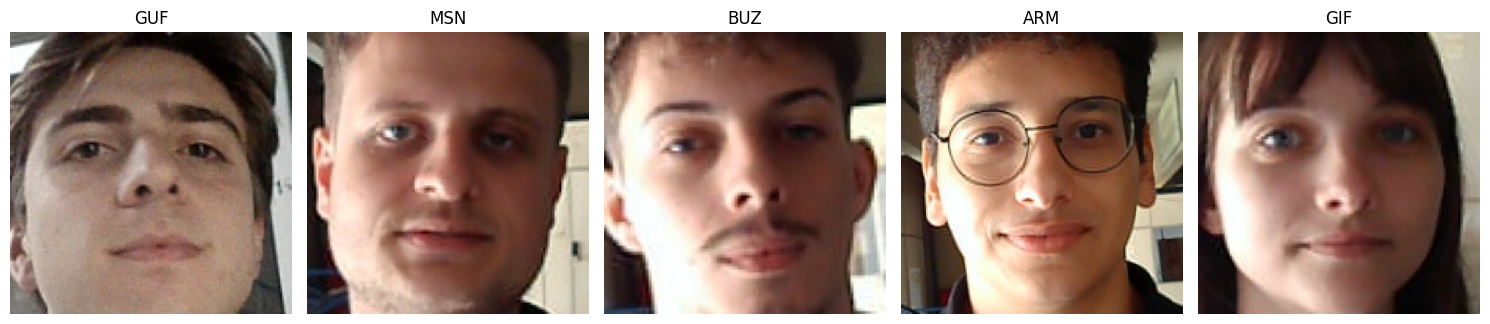

In [3]:
import cv2
import matplotlib.pyplot as plt

# Carrega o classificador Haar Cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
pessoas_sem_rostos = {}
def detectar_face(imagem):
    cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)
    rostos = face_cascade.detectMultiScale(cinza, scaleFactor=1.1, minNeighbors=5)
    
    if len(rostos) == 0:
        return None  # Nenhum rosto detectado
    
    # Seleciona o maior rosto detectado
    x, y, w, h = max(rostos, key=lambda r: r[2] * r[3])
    return imagem[y:y+h, x:x+w]

# Atualiza os rostos nas listas de pessoas
for nome in pessoas:
    faces_detectadas = []
    sem_rostos = []
    for img in pessoas[nome]:
        face = detectar_face(img)
        if face is not None:
            faces_detectadas.append(face)
        else:
            sem_rostos.append(img)
    pessoas[nome] = faces_detectadas
    pessoas_sem_rostos[nome] = sem_rostos


# Atualiza os negativos
negativos_faces = []
for img in negativos:
    face = detectar_face(img)
    if face is not None:
        negativos_faces.append(face)
negativos = negativos_faces

# Resumo
print("Faces detectadas:")
print("Negativos:", len(negativos))
for nome in pessoas:
    print(f"{nome}: {len(pessoas[nome])} rostos detectados")

# Mostrar exemplos de rostos de pessoas
print("\nExemplos de rostos (pessoas):")
fig, axs = plt.subplots(1, 5, figsize=(15, 4))
mostrados = 0
for nome in pessoas:
    if len(pessoas[nome]) > 0:
        axs[mostrados].imshow(cv2.cvtColor(pessoas[nome][0], cv2.COLOR_BGR2RGB))
        axs[mostrados].set_title(nome)
        axs[mostrados].axis('off')
        mostrados += 1
    if mostrados >= 5:
        break
plt.tight_layout()
plt.show()




Exemplos de imagens SEM rosto detectado:


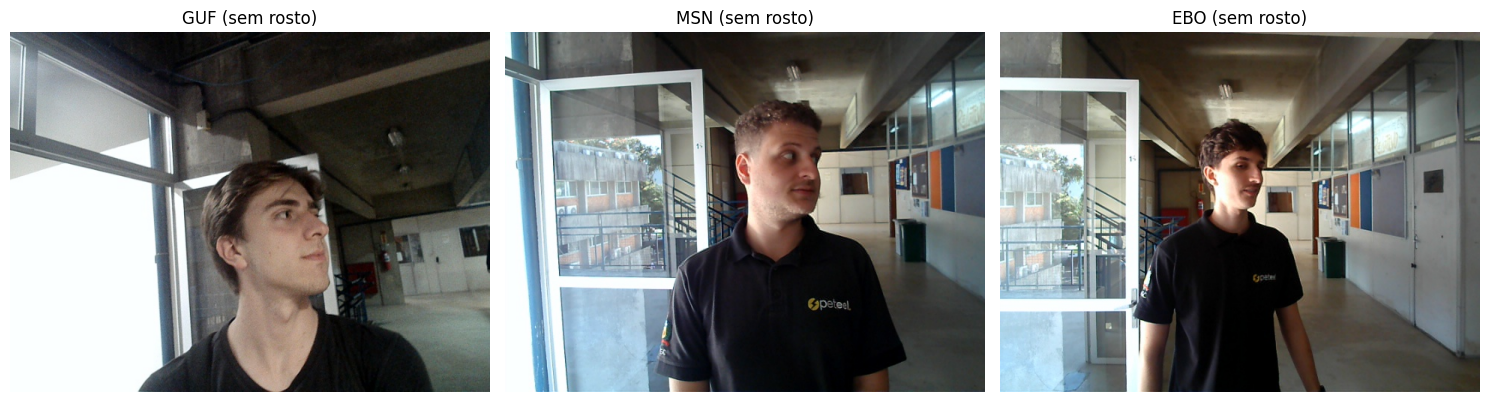

In [4]:
print("\nExemplos de imagens SEM rosto detectado:")
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
mostrados = 0
for nome in pessoas_sem_rostos:
    if len(pessoas_sem_rostos[nome]) > 0:
        axs[mostrados].imshow(cv2.cvtColor(pessoas_sem_rostos[nome][0], cv2.COLOR_BGR2RGB))
        axs[mostrados].set_title(f"{nome} (sem rosto)")
        axs[mostrados].axis('off')
        mostrados += 1
    if mostrados >= 3:
        break
plt.tight_layout()
plt.show()


In [5]:
import os

# Caminhos base
base_path = "/kaggle/working/fotos-treinamento"
positivos_path = os.path.join(base_path, "positivos")
negativos_path = os.path.join(base_path, "negativos")

# Cria diretórios, se não existirem
os.makedirs(positivos_path, exist_ok=True)
os.makedirs(negativos_path, exist_ok=True)

# Salva imagens de pessoas
for nome in pessoas:
    pessoa_path = os.path.join(positivos_path, nome)
    os.makedirs(pessoa_path, exist_ok=True)
    for i, face in enumerate(pessoas[nome]):
        caminho_img = os.path.join(pessoa_path, f"{nome}_{i}.jpg")
        cv2.imwrite(caminho_img, face)

# Salva imagens negativas
for i, face in enumerate(negativos):
    caminho_img = os.path.join(negativos_path, f"neg_{i}.jpg")
    cv2.imwrite(caminho_img, face)

print("Faces salvas em:", base_path)


Faces salvas em: /kaggle/working/fotos-treinamento


### Ver as dimensões das faces

In [6]:
# Função para obter todas as imagens de um diretório (e subdiretórios)
def listar_imagens(diretorio):
    caminhos = []
    for root, _, files in os.walk(diretorio):
        for file in files:
            if file.endswith((".jpg", ".png", ".jpeg")):
                caminhos.append(os.path.join(root, file))
    return caminhos

In [7]:
# Lista de todas as imagens
imagens_positivas = listar_imagens(positivos_path)
imagens_negativas = listar_imagens(negativos_path)
todas_imagens = imagens_positivas + imagens_negativas

# Inicializa variáveis
maior_altura = maior_largura = 0
menor_altura = menor_largura = float('inf')

# Percorre todas as imagens
for caminho in todas_imagens:
    img = cv2.imread(caminho)
    if img is None:
        continue  # ignora arquivos corrompidos
    h, w = img.shape[:2]

    # Atualiza maiores dimensões
    maior_altura = max(maior_altura, h)
    maior_largura = max(maior_largura, w)

    # Atualiza menores dimensões
    menor_altura = min(menor_altura, h)
    menor_largura = min(menor_largura, w)

print(f"Maior dimensão encontrada: {maior_altura}x{maior_largura}")
print(f"Menor dimensão encontrada: {menor_altura}x{menor_largura}")

Maior dimensão encontrada: 244x244
Menor dimensão encontrada: 70x70


375
375


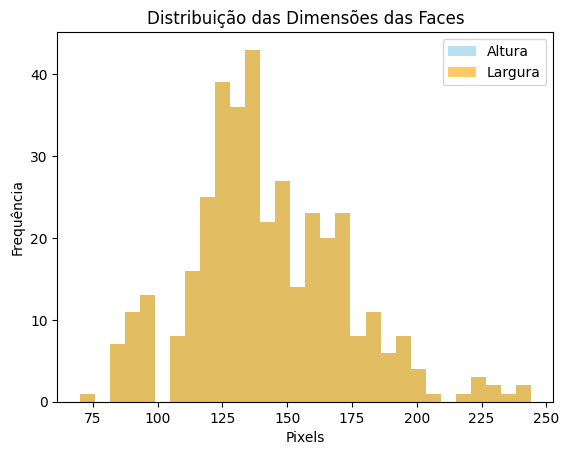

In [8]:
import matplotlib.pyplot as plt

alturas, larguras = [], []

for caminho in todas_imagens:
    img = cv2.imread(caminho)
    if img is not None:
        h, w = img.shape[:2]
        alturas.append(h)
        larguras.append(w)
print(len(alturas))
print(len(larguras))

plt.hist(alturas, bins=30, alpha=0.6, label='Altura', color='skyblue')
plt.hist(larguras, bins=30, alpha=0.6, label='Largura', color='orange')

plt.legend()
plt.title("Distribuição das Dimensões das Faces")
plt.xlabel("Pixels")
plt.ylabel("Frequência")
plt.show()


In [9]:
from scipy import stats
import numpy as np
dimensoes = larguras  
media = int(np.mean(dimensoes))
mediana = int(np.median(dimensoes))
moda = int(stats.mode(dimensoes, keepdims=True)[0][0])

print(f"Média: {media}x{media}")
print(f"Mediana: {mediana}x{mediana}")
print(f"Moda: {moda}x{moda}")

Média: 142x142
Mediana: 138x138
Moda: 126x126


Vamos fixar primeiro todas as ROIs em 142x142

In [10]:
# Caminhos de saída
saida_base = "/kaggle/working/faces_dataset"
saida_positivos = os.path.join(saida_base, "positivos_redimensionados")
saida_negativos = os.path.join(saida_base, "negativos_redimensionados")

os.makedirs(saida_positivos, exist_ok=True)
os.makedirs(saida_negativos, exist_ok=True)

In [11]:
# Redimensiona imagens positivas com subpastas (nomes das pessoas)
for caminho in listar_imagens(positivos_path):
    img = cv2.imread(caminho)
    if img is not None:
        img_resized = cv2.resize(img, (media, media))
        # Subpasta com nome da pessoa
        nome_pessoa = os.path.basename(os.path.dirname(caminho))
        destino_dir = os.path.join(saida_positivos, nome_pessoa)
        os.makedirs(destino_dir, exist_ok=True)
        nome_arquivo = os.path.basename(caminho)
        cv2.imwrite(os.path.join(destino_dir, nome_arquivo), img_resized)

# Redimensiona imagens negativas diretamente
for caminho in listar_imagens(negativos_path):
    img = cv2.imread(caminho)
    if img is not None:
        img_resized = cv2.resize(img, (media, media))
        nome_arquivo = os.path.basename(caminho)
        cv2.imwrite(os.path.join(saida_negativos, nome_arquivo), img_resized)

print("Redimensionamento concluído!")
print(f"Imagens salvas em: {saida_base}")

Redimensionamento concluído!
Imagens salvas em: /kaggle/working/faces_dataset


In [12]:
from tqdm import tqdm
# Caminhos para os diretórios
path_positivos = "/kaggle/working/faces_dataset/positivos_redimensionados"
path_negativos = "/kaggle/working/faces_dataset/negativos_redimensionados"

# Listas finais
X = []
y = []

# Carrega os positivos
for pessoa in os.listdir(path_positivos):
    pasta_pessoa = os.path.join(path_positivos, pessoa)
    if os.path.isdir(pasta_pessoa):
        for arquivo in os.listdir(pasta_pessoa):
            if arquivo.endswith(".jpg") or arquivo.endswith(".png"):
                img_path = os.path.join(pasta_pessoa, arquivo)
                img = cv2.imread(img_path)
                X.append(img)
                y.append(pessoa)  # o nome da pasta vira o label

# Carrega os negativos
for arquivo in os.listdir(path_negativos):
    if arquivo.endswith(".jpg") or arquivo.endswith(".png"):
        img_path = os.path.join(path_negativos, arquivo)
        img = cv2.imread(img_path)
        X.append(img)
        y.append("desconhecido")

# Converte para numpy arrays
X = np.array(X)
y = np.array(y)
print(f'{len(X)=},{len(y)=}')

len(X)=375,len(y)=375


In [13]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Checando proporções
print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))


Treino: 225
Validação: 75
Teste: 75


In [14]:
from sklearn.preprocessing import LabelEncoder

# Cria o codificador
le = LabelEncoder()

# Ajusta e transforma os rótulos
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

# (opcional) Veja o mapeamento das classes
print("Classes codificadas:", le.classes_)


Classes codificadas: ['ARM' 'BUZ' 'EBO' 'GIF' 'GUF' 'MSN' 'desconhecido']


# Etapa de melhoria de iluminação

Conforme benchmark feito pelo notebook de preprocessamento_imagem, iremos utilizar a correção gamma e a equalização de histograma localizada

Função para correção gamma

In [15]:
def definir_gamma(media_pixel):
    # Ajuste baseado na média da imagem
    if media_pixel < 80:
        return 0.4  # imagem muito escura, clarear bastante
    elif media_pixel < 120:
        return 0.7  # escura, clarear
    elif media_pixel < 140:
        return 1.0  # gamma neutro
    elif media_pixel < 180:
        return 1.3  # clara, escurecer um pouco
    else:
        return 1.6  # muito clara, escurecer mais

def gamma_correction(image, gamma):
    # Normaliza para [0, 1]
    normalized = image / 255.0
    # Aplica correção gama
    corrected = np.power(normalized, gamma)
    # Converte de volta para [0, 255]
    result = np.uint8(corrected * 255)
    return result

Instanciando objeto da classe CLAHE para equalização de histograma localizada

In [16]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# Reconhecimento facial -> Sem data augmentation e sem processamento de imagem

In [17]:
from tensorflow.keras.applications import MobileNetV2

def make_model_fine_tuning(n_classes, preprocess_input, img_size):

    input_shape = img_size + (3,)  

    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False
    for layer in base_model.layers:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    keras.utils.set_random_seed(0)
    model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
    ])
    model.summary()
    return model

2025-08-07 14:57:52.289624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754578672.466314      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754578672.517770      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, LearningRateScheduler

Plotar exemplos de fotos na entrada da rede

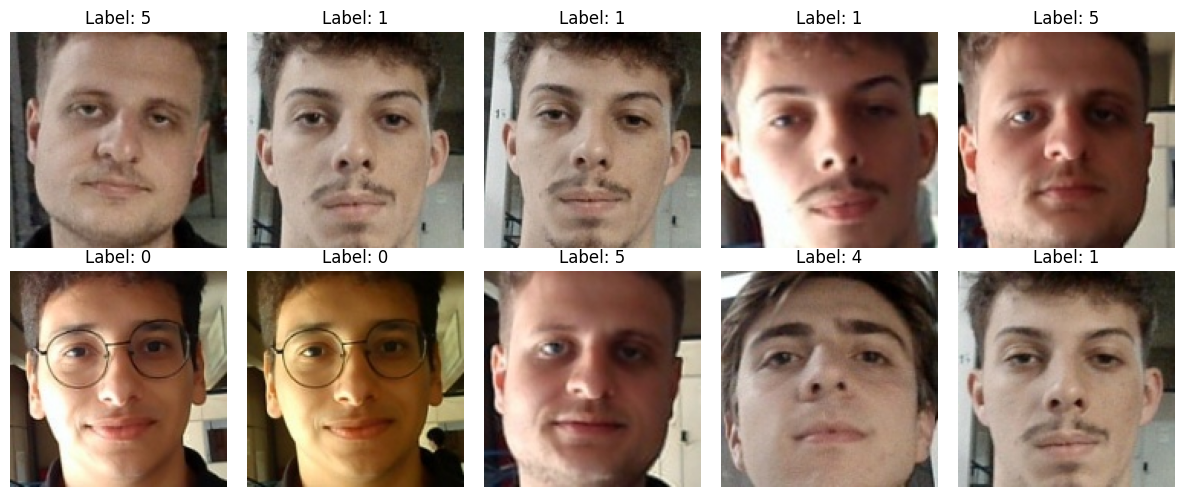

In [19]:
plt.figure(figsize=(12, 5))

i = 0  # contador de imagens plotadas
j = 0  # índice de iteração sobre X_train

while i < 10 and j < len(X_train):
    label = y_train[j]
    
    # pula imagens com label 6
    if label == 6:
        j += 1
        continue
    
    plt.subplot(2, 5, i + 1)
    img = X_train[j]
    
    # Se a imagem estiver em float (normalizada), converte para uint8
    if img.dtype != 'uint8':
        img = (img * 255).astype('uint8')
    
    # Corrige o canal de cores BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img_rgb)
    plt.title(f"Label: {label}")
    plt.axis('off')
    
    i += 1
    j += 1

plt.tight_layout()
plt.show()

/tmp/ipykernel_19/1455136058.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
I0000 00:00:1754578686.727572      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15257 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                      │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 2,198,727 (8.39 MB)

 Non-trainable params: 68,224 (266.50 KB)

I0000 00:00:1754578703.193919      70 service.cc:148] XLA service 0x7e0ba0005030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754578703.194496      70 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1754578704.584521      70 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1754578708.093583      70 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1754578708.288701      70 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1754578713.590274      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 10: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 18: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.

Epoch 21: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.

Epoch 24: ReduceLROnPlateau reducing learning rate to 1.600000018697756e-07.


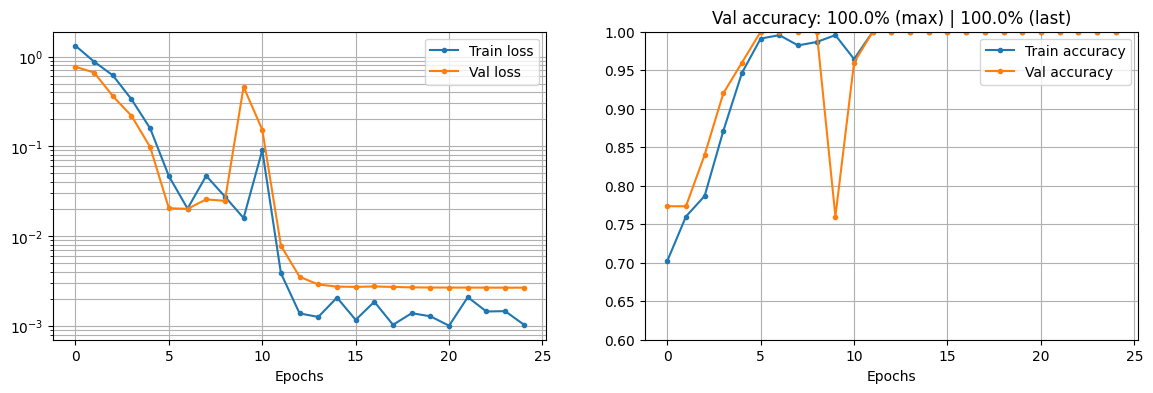

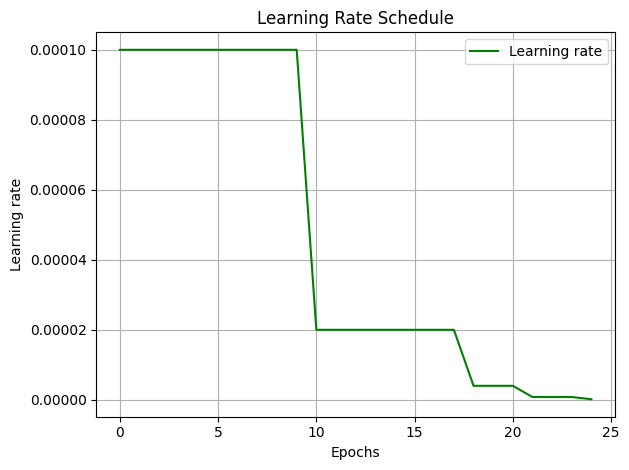

In [20]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_fine_tuning(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=25,
    callbacks=callbacks,
    verbose=0
)

# Plot de acurácia e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
test_loss, test_accuracy = model.evaluate(X_test,y_test, verbose=1)

print(f"\n Acurácia no conjunto de teste: {test_accuracy:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 1.0000 - loss: 0.0064

 Acurácia no conjunto de teste: 1.0000
Loss no conjunto de teste: 0.0073


# Com data augmentation, sem processamento de imagem

In [22]:
def make_model_data_augmentation(n_classes, preprocess_input, img_size):
    input_shape = img_size + (3,)

    # Data Augmentation pipeline
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),                      # flip horizontal
        layers.RandomRotation(0.04),                          # +/- 15° = 15/360 = ~0.04
        layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),  # zoom in/out 10%
        layers.RandomContrast(0.1),                           # variação de contraste ±10%
        layers.RandomBrightness(factor=0.1),                   # variação de brilho ±10%
    ], name="data_augmentation")

    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    
    # Congela todas camadas menos BatchNormalization
    base_model.trainable = False
    for layer in base_model.layers:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    keras.utils.set_random_seed(0)
    
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)          # aplica data augmentation
    x = layers.Lambda(preprocess_input)(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.summary()
    return model

/tmp/ipykernel_19/2412352408.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_1 (Lambda)                    │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 2,198,727 (8.39 MB)

 Non-trainable params: 68,224 (266.50 KB)


Epoch 15: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.


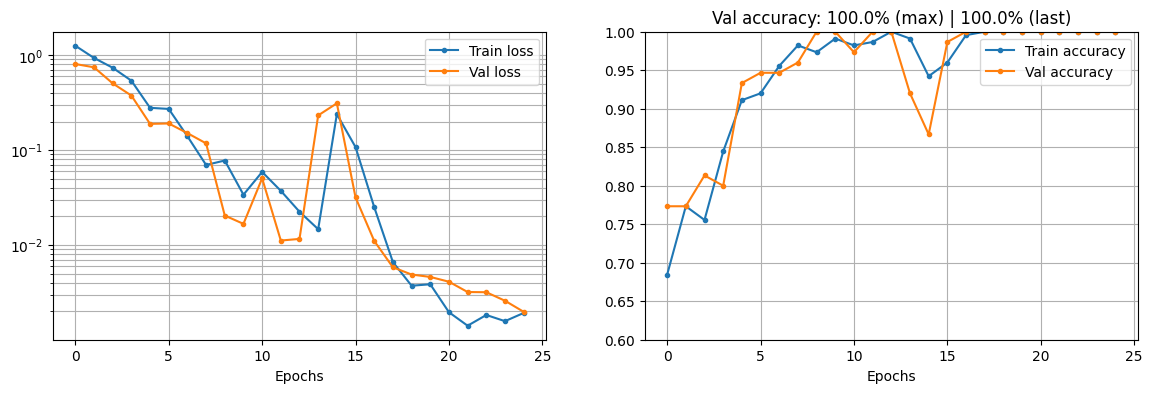

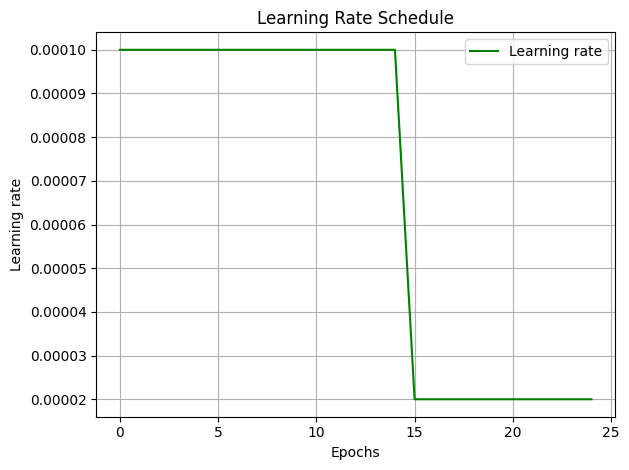

In [23]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_data_augmentation(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=25,
    callbacks=callbacks,
    verbose=0
)

# Plot de acurácia e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Vou aumentar um pouco o número de épocas para ver se melhoramos o resultado

/tmp/ipykernel_19/2412352408.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lambda_2 (Lambda)                    │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 2,198,727 (8.39 MB)

 Non-trainable params: 68,224 (266.50 KB)


Epoch 14: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 29: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.

Epoch 34: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.


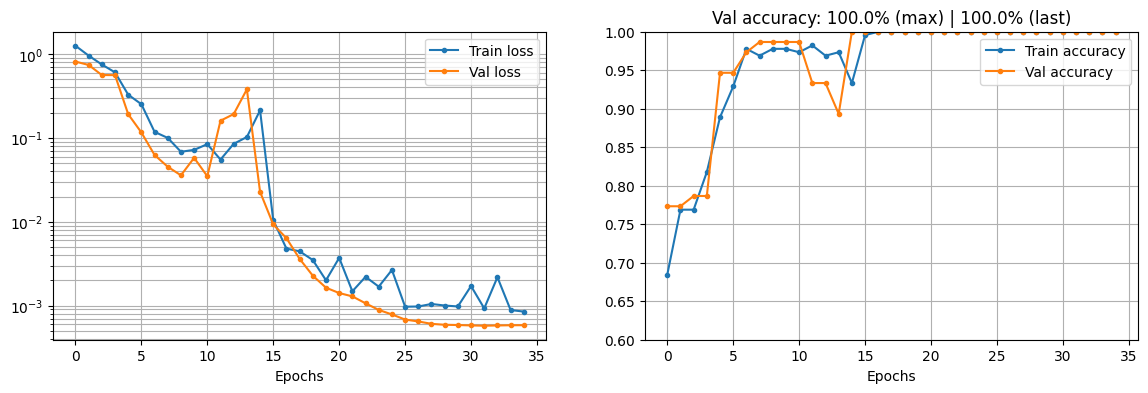

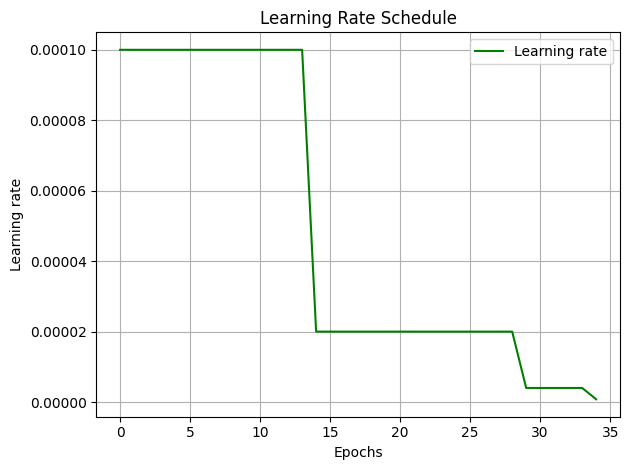

In [24]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_data_augmentation(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=35,
    callbacks=callbacks,
    verbose=0
)

# Plot de acurácia e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
test_loss, test_accuracy = model.evaluate(X_test,y_test, verbose=1)

print(f"\n Acurácia no conjunto de teste: {test_accuracy:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0058     

 Acurácia no conjunto de teste: 1.0000
Loss no conjunto de teste: 0.0072


Estamos tendo 100% de acurácia, mas isso se deve ao fato de ter poucas imagens, vou aumentar o número de imagens em 5 vezes usando data augmentation

In [26]:
!pip install albumentations opencv-python

In [27]:
import albumentations as A

import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=1.0),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=1.0),
    A.RandomResizedCrop(size=(X.shape[1], X.shape[2]), scale=(0.8, 1.0), p=1.0)
])



def augment_dataset(X, Y, n_aug=5):
    X_augmented = []
    Y_augmented = []
    
    for img, label in zip(X, Y):
        # adiciona a imagem original
        X_augmented.append(img)
        Y_augmented.append(label)
        
        # gera n_aug versões aumentadas
        for _ in range(n_aug):
            augmented = transform(image=img)['image']
            X_augmented.append(augmented)
            Y_augmented.append(label)
    
    X_augmented = np.array(X_augmented)
    Y_augmented = np.array(Y_augmented)
    return X_augmented, Y_augmented

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [28]:
X_new, y_new = augment_dataset(X, y, n_aug=4)
print(f'{X_new.shape[0]} = 5x{X.shape[0]}')  # vai ter 5x o número de imagens originais
print(f'{y_new.shape[0]} = 5x{y.shape[0]}')

1875 = 5x375
1875 = 5x375


In [29]:
5*375

1875

In [30]:
X_new.shape

(1875, 142, 142, 3)

In [31]:
X.shape

(375, 142, 142, 3)

Refazendo os conjuntos

In [32]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_new, y_new, test_size=0.2, stratify=y_new, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Checando proporções
print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))

Treino: 1125
Validação: 375
Teste: 375


In [33]:
from sklearn.preprocessing import LabelEncoder

# Cria o codificador
le = LabelEncoder()

# Ajusta e transforma os rótulos
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

# (opcional) Veja o mapeamento das classes
print("Classes codificadas:", le.classes_)


Classes codificadas: ['ARM' 'BUZ' 'EBO' 'GIF' 'GUF' 'MSN' 'desconhecido']


/tmp/ipykernel_19/1455136058.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)                    │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 2,198,727 (8.39 MB)

 Non-trainable params: 68,224 (266.50 KB)


Epoch 12: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 15: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.

Epoch 18: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.

Epoch 21: ReduceLROnPlateau reducing learning rate to 1.600000018697756e-07.

Epoch 24: ReduceLROnPlateau reducing learning rate to 3.199999980552093e-08.


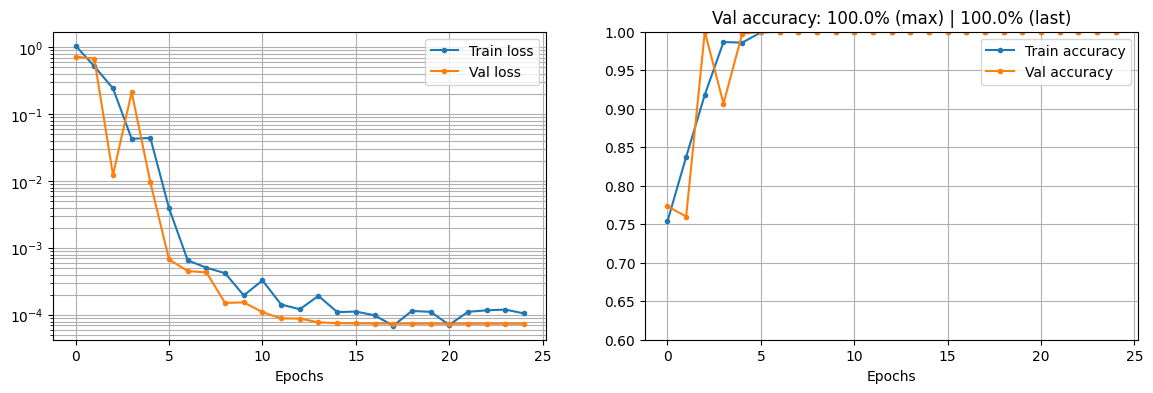

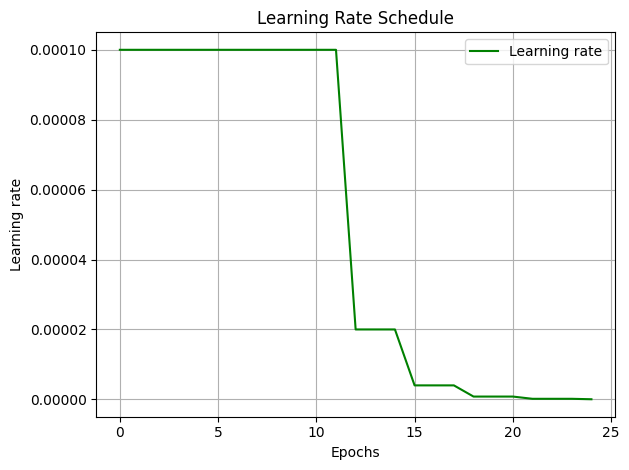

In [34]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_fine_tuning(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=16,
    epochs=25,
    callbacks=callbacks,
    verbose=0
)

# Plot de acurácia e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
test_loss, test_accuracy = model.evaluate(X_test,y_test, verbose=1)

print(f"\n Acurácia no conjunto de teste: {test_accuracy:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 1.0000 - loss: 2.8081e-04

 Acurácia no conjunto de teste: 1.0000
Loss no conjunto de teste: 0.0008


In [36]:
from sklearn.metrics import balanced_accuracy_score
import numpy as np

y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nAcurácia balanceada no conjunto de teste: {balanced_acc:.4f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step

Acurácia balanceada no conjunto de teste: 1.0000


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


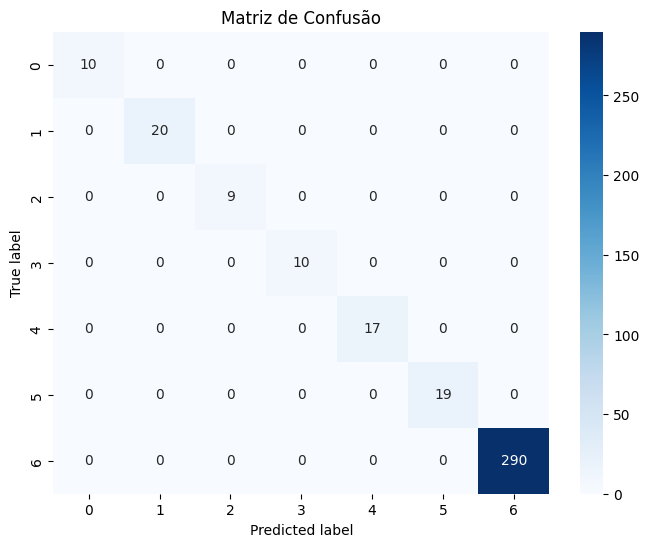

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# 1. Obter as predições (probabilidades)
y_pred_prob = model.predict(X_test)

# 2. Converter para classes preditas
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. Usar os rótulos reais diretamente
y_true = y_test

# 4. Calcular a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 5. Exibir a matriz de confusão
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Matriz de Confusão')
plt.show()

# Utilizando o processamento de melhoria de imagem

In [38]:
def preprocess_image_custom(image):
    # Converte para YCrCb
    ycrcb = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb)
    
    # CLAHE no canal de luminância
    y_eq = clahe.apply(y)
    ycrcb_eq = cv2.merge((y_eq, cr, cb))
    image_eq = cv2.cvtColor(ycrcb_eq, cv2.COLOR_YCrCb2RGB)

    # Correção gamma baseada na média
    media_pixel = np.mean(image_eq)
    gamma = definir_gamma(media_pixel)
    image_gamma = gamma_correction(image_eq, gamma)

    return image_gamma

Criando conjuntos de imagens com melhoria na iluminação

In [39]:
X_train_pp = np.array([preprocess_image_custom(img) for img in X_train])
X_val_pp   = np.array([preprocess_image_custom(img) for img in X_val])
X_test_pp  = np.array([preprocess_image_custom(img) for img in X_test])

Plotando exemplos na entrada da rede com data augmentation, mas sem melhoria de iluminação

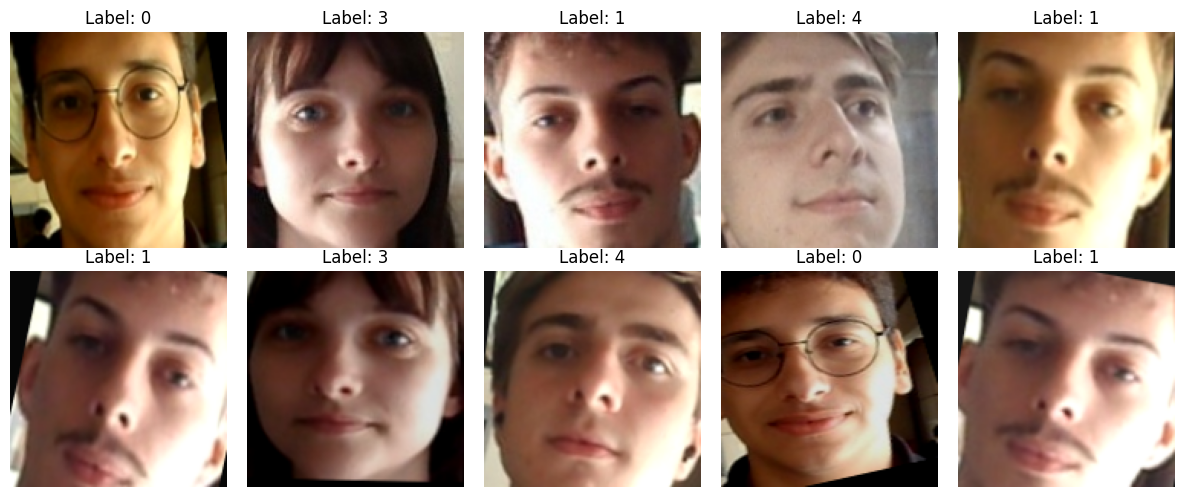

In [40]:
plt.figure(figsize=(12, 5))

i = 0  # contador de imagens plotadas
j = 0  # índice do dataset

while i < 10 and j < len(X_train):
    if y_train[j] == 6:
        j += 1
        continue

    plt.subplot(2, 5, i + 1)
    img = X_train[j]

    # Se a imagem estiver em float (normalizada), converta para uint8
    if img.dtype != 'uint8':
        img = (img * 255).astype('uint8')

    # Corrige o canal de cores BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(f"Label: {y_train[j]}")
    plt.axis('off')

    i += 1
    j += 1

plt.tight_layout()
plt.show()


Plotando a entrada com melhoria de iluminação APÓS aplicar o data augmentation

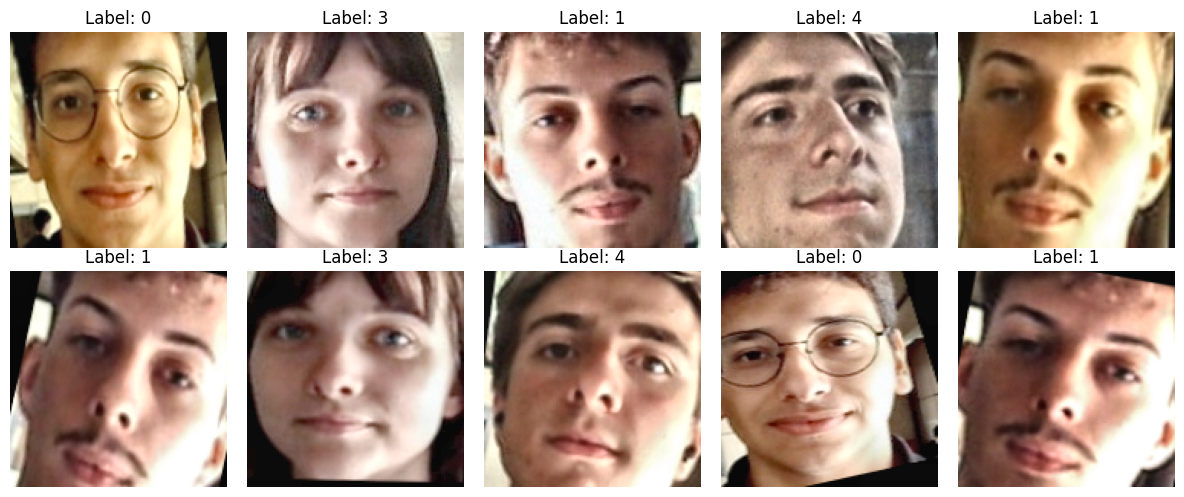

In [41]:
plt.figure(figsize=(12, 5))

i = 0  # contador de imagens plotadas
j = 0  # índice do dataset

while i < 10 and j < len(X_train_pp):
    if y_train[j] == 6:
        j += 1
        continue

    plt.subplot(2, 5, i + 1)
    img = X_train_pp[j]

    # Se a imagem estiver em float (normalizada), converta para uint8
    if img.dtype != 'uint8':
        img = (img * 255).astype('uint8')

    # Corrige o canal de cores BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title(f"Label: {y_train[j]}")
    plt.axis('off')

    i += 1
    j += 1

plt.tight_layout()
plt.show()


/tmp/ipykernel_19/1455136058.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_4 (Lambda)                    │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_4           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 2,198,727 (8.39 MB)

 Non-trainable params: 68,224 (266.50 KB)


Epoch 11: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 14: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.

Epoch 17: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.

Epoch 20: ReduceLROnPlateau reducing learning rate to 1.600000018697756e-07.

Epoch 23: ReduceLROnPlateau reducing learning rate to 3.199999980552093e-08.


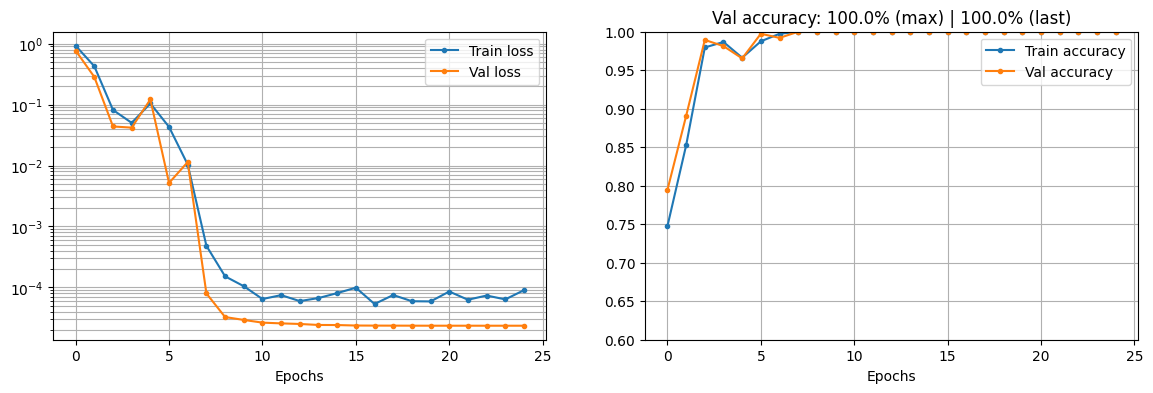

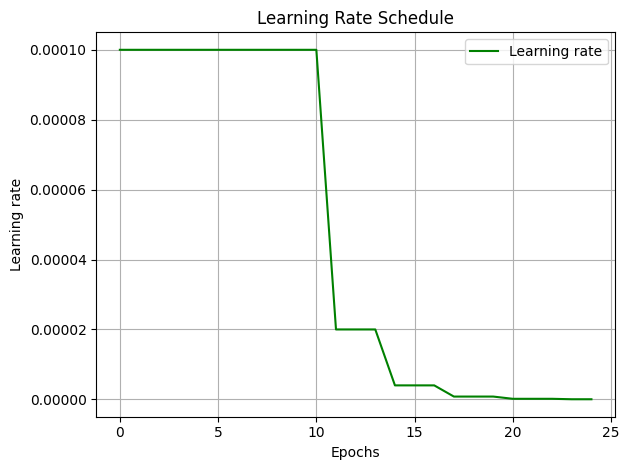

In [42]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_fine_tuning(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento
history = model.fit(
    X_train_pp, y_train,
    validation_data=(X_val_pp, y_val),
    batch_size=16,
    epochs=25,
    callbacks=callbacks,
    verbose=0
)

# Plot de acurácia e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
test_loss, test_accuracy = model.evaluate(X_test_pp,y_test, verbose=1)

print(f"\n Acurácia no conjunto de teste: {test_accuracy:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 1.0000 - loss: 4.5820e-05

 Acurácia no conjunto de teste: 1.0000
Loss no conjunto de teste: 0.0001


In [44]:
y_pred_probs = model.predict(X_test_pp)

y_pred = np.argmax(y_pred_probs, axis=1)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\nAcurácia balanceada no conjunto de teste: {balanced_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 280ms/step

Acurácia balanceada no conjunto de teste: 1.0000


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


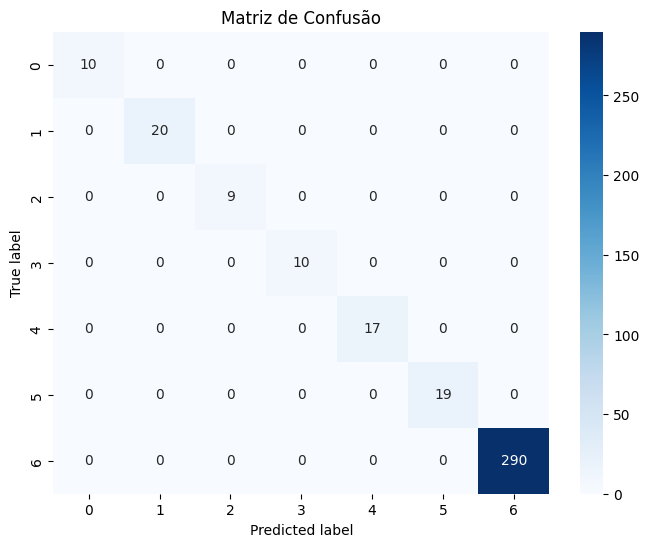

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# 1. Obter as predições (probabilidades)
y_pred_prob = model.predict(X_test_pp)

# 2. Converter para classes preditas
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. Usar os rótulos reais diretamente
y_true = y_test

# 4. Calcular a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 5. Exibir a matriz de confusão
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Matriz de Confusão')
plt.show()

### Nova hipótese: buscar melhorar a acurácia balanceada aplicando melhoria de imagem na imagem antes de aplicar data augmentation

In [46]:
X_pp = np.array([preprocess_image_custom(img) for img in X])


In [47]:
print(len (y))
len(X_pp)

375


375

In [48]:
from sklearn.model_selection import train_test_split

X_temp, X_test_pp, y_temp, y_test_pp = train_test_split(
    X_pp, y, test_size=0.2, stratify=y, random_state=42)

X_train_pp, X_val_pp, y_train_pp, y_val_pp = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Checando proporções
print("Treino:", len(X_train_pp))
print("Validação:", len(X_val_pp))
print("Teste:", len(X_test_pp))

Treino: 225
Validação: 75
Teste: 75


Refazendo o data augmentation nas imagens com melhoria de iluminação

In [49]:
X_train_pp_aug, y_train_pp_aug = augment_dataset(X_train_pp, y_train_pp, n_aug=5)
X_val_pp_aug, y_val_pp_aug = augment_dataset(X_val_pp, y_val_pp, n_aug=5)
X_test_pp_aug, y_test_pp_aug = augment_dataset(X_test_pp, y_test_pp, n_aug=5)



### Fotos com melhoria de iluminação antes do data augmentation

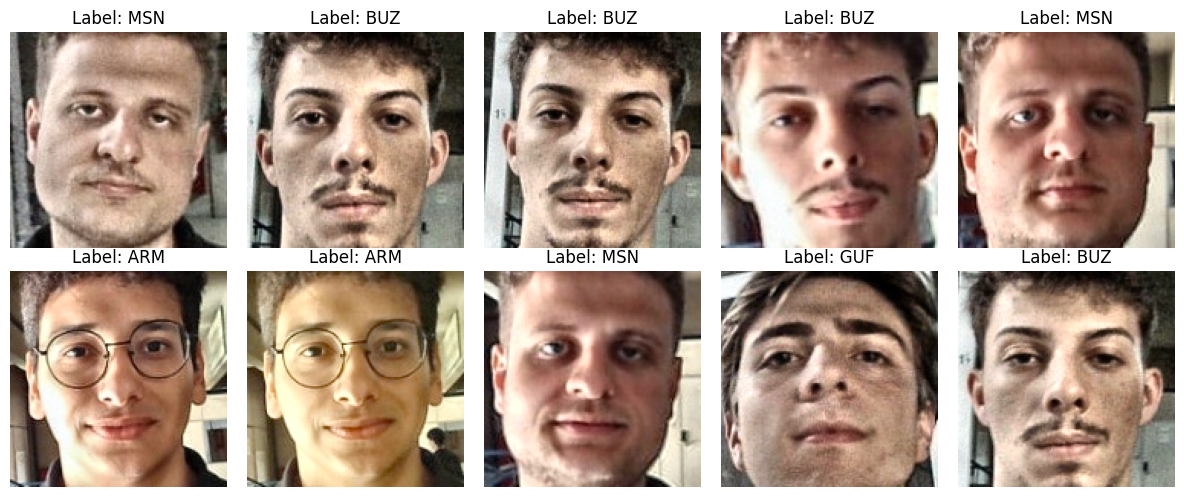

In [50]:
plt.figure(figsize=(12, 5))
plot_idx = 1  # índice do subplot (de 1 a 10)
i = 0         # índice das imagens

while plot_idx <= 10 and i < len(X_train_pp):
    if y_train_pp[i] == "desconhecido":
        i += 1
        continue  # pula a imagem com label 6

    img = X_train_pp[i]

    # Se a imagem estiver em float (normalizada), converta para uint8
    if img.dtype != 'uint8':
        img = (img * 255).astype('uint8')

    # Corrige o canal de cores BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, plot_idx)
    plt.imshow(img_rgb)
    plt.title(f"Label: {y_train_pp[i]}")
    plt.axis('off')

    plot_idx += 1
    i += 1

plt.tight_layout()
plt.show()


Fotos com melhoria de iluminação **depois** do data augmentation

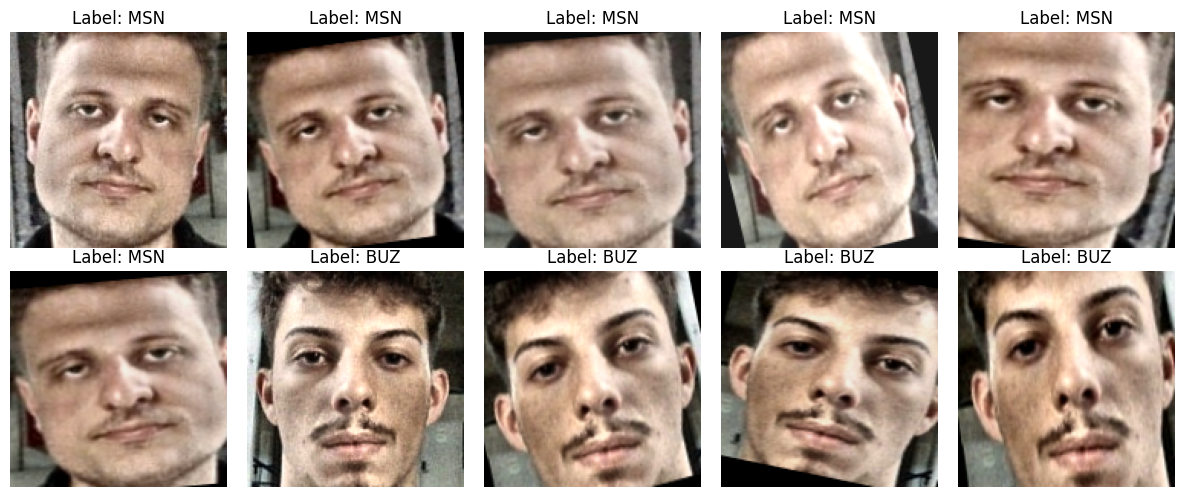

In [51]:
plt.figure(figsize=(12, 5))
plot_idx = 1
i = 0

while plot_idx <= 10 and i < len(X_train_pp_aug):
    if y_train_pp_aug[i] == "desconhecido":
        i += 1
        continue  # pula imagem com label "desconhecido"

    img = X_train_pp_aug[i]

    # Se a imagem estiver em float (normalizada), converta para uint8
    if img.dtype != 'uint8':
        img = (img * 255).astype('uint8')

    # Corrige o canal de cores BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, plot_idx)
    plt.imshow(img_rgb)
    plt.title(f"Label: {y_train_pp_aug[i]}")
    plt.axis('off')

    plot_idx += 1
    i += 1

plt.tight_layout()
plt.show()


In [52]:
# Ajusta e transforma os rótulos
y_train_pp_aug = le.fit_transform(y_train_pp_aug)
y_val_pp_aug = le.transform(y_val_pp_aug)
y_test_pp_aug = le.transform(y_test_pp_aug)

# (opcional) Veja o mapeamento das classes
print("Classes codificadas:", le.classes_)

Classes codificadas: ['ARM' 'BUZ' 'EBO' 'GIF' 'GUF' 'MSN' 'desconhecido']


/tmp/ipykernel_19/1455136058.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_5 (Lambda)                    │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_5           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │           8,967 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 2,198,727 (8.39 MB)

 Non-trainable params: 68,224 (266.50 KB)


Epoch 11: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 14: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.

Epoch 17: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.

Epoch 20: ReduceLROnPlateau reducing learning rate to 1.600000018697756e-07.


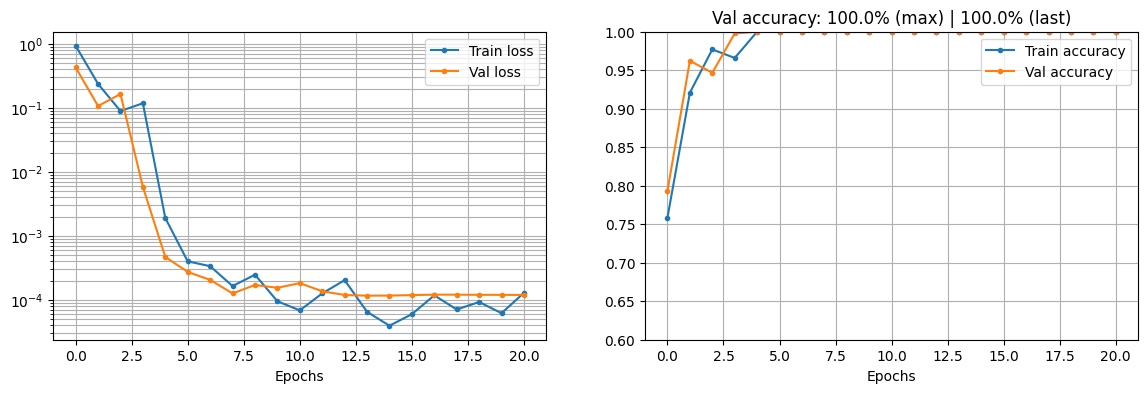

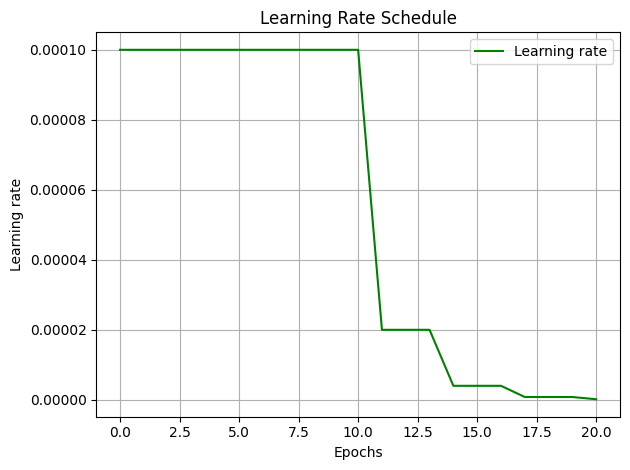

In [53]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_fine_tuning(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento
history = model.fit(
    X_train_pp_aug, y_train_pp_aug,
    validation_data=(X_val_pp_aug, y_val_pp_aug),
    batch_size=16,
    epochs=25,
    callbacks=callbacks,
    verbose=0
)

# Plot de acurácia e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
# Ajusta e transforma os rótulos
y_test_p = le.fit_transform(y_test_pp)

# (opcional) Veja o mapeamento das classes
print("Classes codificadas:", le.classes_)

Classes codificadas: ['ARM' 'BUZ' 'EBO' 'GIF' 'GUF' 'MSN' 'desconhecido']


In [55]:
test_loss, test_accuracy = model.evaluate(X_test_pp,y_test_p, verbose=1)

print(f"\n Acurácia no conjunto de teste: {test_accuracy:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 721ms/step - accuracy: 0.9894 - loss: 0.0314

 Acurácia no conjunto de teste: 0.9867
Loss no conjunto de teste: 0.0396


In [56]:
y_pred_probs = model.predict(X_test_pp_aug)

y_pred = np.argmax(y_pred_probs, axis=1)

balanced_acc = balanced_accuracy_score(y_test_pp_aug, y_pred)

print(f"\nAcurácia balanceada no conjunto de teste: {balanced_acc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step

Acurácia balanceada no conjunto de teste: 0.9861


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


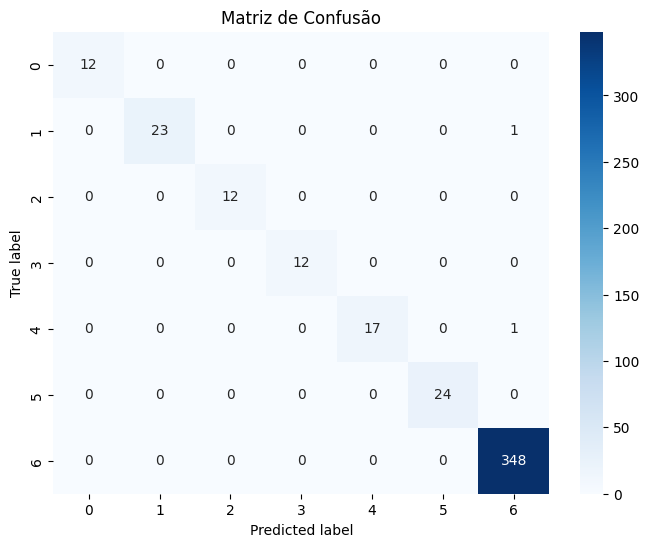

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# 1. Obter as predições (probabilidades)
y_pred_prob = model.predict(X_test_pp_aug)

# 2. Converter para classes preditas
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. Usar os rótulos reais diretamente
y_true = y_test_pp_aug

# 4. Calcular a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 5. Exibir a matriz de confusão
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Matriz de Confusão')
plt.show()

# Mudança de paradigma

No momento, estou fazendo a partição dos meus dados dessa forma: imagens positivas e negativas sendo particionadas, na mesma proporção de classes, em treino, validação e teste.

Essa não é a forma mais **generalista** que posso fazer, uma vez que meu problema sempre vai supor uma classe **(closed set)**. Irei testar uma nova abordagem, vou treinar meu modelo apenas com faces que quero que sejam reconhecidas. Dessa forma, a função de ativação da minha camada de saída deve ser uma sigmóide, de forma que eu faça uma predição multiclasse **"one versus all"**, necessitando implementar um novo hiperparâmetro, um **threshold** para que no conjunto de teste, onde será utilizado faces não permitidas, faces que tenham no neurônio com a maior saída da sigmoide um valor abaixo do threshold sejam classificadas como desconhecidas.

Abaixo teremos a verificação dessas hipóteses, assim como a revalidação da hipótese de que aplicar técnicas de melhoria incrementa o aproveitamento do algoritmo, aumentando a métrica de acurácia balanceada

Refazendo os conjuntos

In [58]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Checando proporções
print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))


Treino: 225
Validação: 75
Teste: 75


Será necessário retirar as imagens negativas nos conjuntos de treino e validação e coloca-los no teste

In [59]:
CLASSE_DESCONHECIDA='desconhecido'
def filtrar_desconhecidos(X, y, classe_desconhecida):
    mask = y != classe_desconhecida
    return X[mask], y[mask], X[~mask], y[~mask]

X_train, y_train, X_desconhecidos_train, y_desconhecidos_train = filtrar_desconhecidos(X_train, y_train, CLASSE_DESCONHECIDA)

X_test = np.concatenate([X_test, X_desconhecidos_train], axis=0)
y_test = np.concatenate([y_test, y_desconhecidos_train], axis=0)

print("Treino:", len(X_train))
print("Validação:", len(X_val))
print("Teste:", len(X_test))
print("Total desconhecidos no teste:", np.sum(y_test == CLASSE_DESCONHECIDA))

Treino: 51
Validação: 75
Teste: 249
Total desconhecidos no teste: 232


Mudando o modelo para saída sigmoide

In [60]:
from tensorflow.keras.applications import MobileNetV2

def make_model_fine_tuning_sigmoid(n_classes, preprocess_input, img_size):
    n_classes=n_classes-1 #tirando a classe desconhecida
    input_shape = img_size + (3,)  

    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False
    for layer in base_model.layers:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    keras.utils.set_random_seed(3)
    model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='sigmoid')
    ])
    model.summary()
    return model

# Aplicando o data augmentation

In [61]:
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, n_aug=5)
X_val_aug, y_val_aug = augment_dataset(X_val, y_val, n_aug=5)

In [62]:
# Ajusta e transforma os rótulos
le = LabelEncoder()

y_test_aug = le.fit_transform(y_test)
#y_train_aug = le.transform(y_train_aug)
y_val_aug = le.transform(y_val_aug)

# (opcional) Veja o mapeamento das classes
print("Classes codificadas:", le.classes_)

Classes codificadas: ['ARM' 'BUZ' 'EBO' 'GIF' 'GUF' 'MSN' 'desconhecido']


In [63]:
# Ajusta e transforma os rótulos
le = LabelEncoder()

y_train_aug = le.fit_transform(y_train_aug)

# (opcional) Veja o mapeamento das classes
print("Classes codificadas:", le.classes_)

Classes codificadas: ['ARM' 'BUZ' 'EBO' 'GIF' 'GUF' 'MSN']


Transformar para One-hot categórico

In [64]:
from tensorflow.keras.utils import to_categorical

y_train_aug_oh = to_categorical(y_train_aug, num_classes=n_classes-1)
y_val_aug_oh = to_categorical(y_val_aug, num_classes=n_classes)
y_test_aug_oh = to_categorical(y_test_aug, num_classes=n_classes)

In [65]:
# Supondo y_val_aug_oh e y_test_aug_oh com shape (num_amostras, 7)
# Remove o último elemento (coluna) de cada vetor

y_val_aug_oh = y_val_aug_oh[:, :-1]
y_test_aug_oh = y_test_aug_oh[:, :-1]


/tmp/ipykernel_19/358042524.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_6 (Lambda)                    │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_6           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 2,197,446 (8.38 MB)

 Non-trainable params: 68,224 (266.50 KB)


Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 8: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.


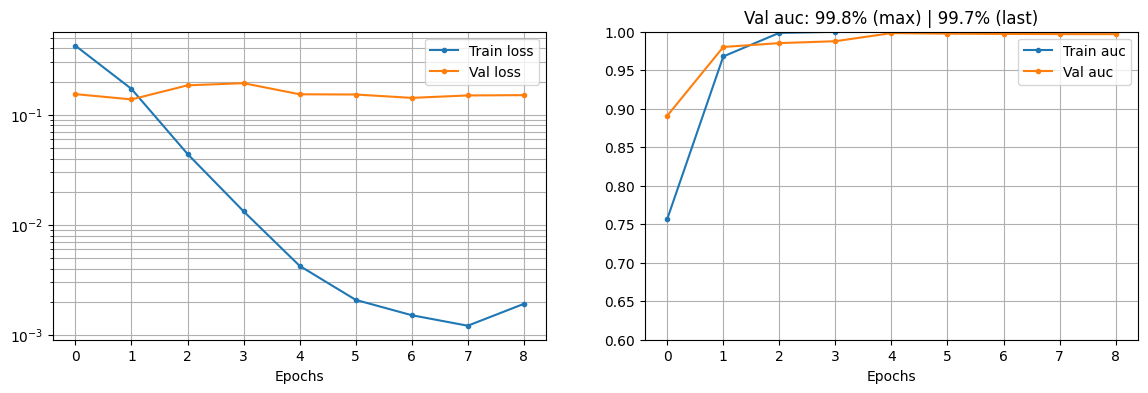

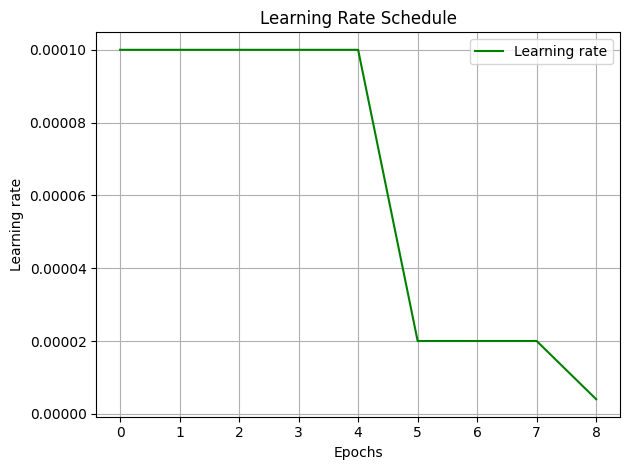

In [66]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_fine_tuning_sigmoid(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
# Treinamento
history = model.fit(
    X_train_aug, y_train_aug_oh,
    validation_data=(X_val_aug, y_val_aug_oh),
    batch_size=16,
    epochs=25,
    callbacks=callbacks,
    verbose=0
)

# Plot de AUC e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Escolher threshold agora a partir de curva ROC

In [67]:
y_pred_probs = model.predict(X_val_aug)
y_true = np.array([
    -1 if np.all(y == 0) else np.argmax(y)
    for y in y_val_aug_oh
])

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step


In [68]:
from sklearn.metrics import balanced_accuracy_score

def evaluate_threshold(y_probs, y_true, threshold):
    y_pred = []
    for p in y_probs:
        if np.max(p) < threshold:
            y_pred.append(-1)
        else:
            y_pred.append(np.argmax(p))
    return balanced_accuracy_score(y_true, y_pred)


In [69]:
import pandas as pd
thresholds = np.linspace(0.1, 0.9, 81)
scores = [evaluate_threshold(y_pred_probs, y_true, t) for t in thresholds]

best_idx = np.argmax(scores)
best_threshold = thresholds[best_idx]
best_score = scores[best_idx]
print(f"Melhor threshold: {best_threshold:.2f} com F1-score (macro): {best_score:.4f}")

df_thresholds = pd.DataFrame({
    'Threshold': thresholds,
    'Balanced_accuracy': scores
})
top_10 = df_thresholds.sort_values(by='Balanced_accuracy', ascending=False).head(10).reset_index(drop=True)
print("\nTop 10 thresholds:")
print(top_10)

Melhor threshold: 0.90 com F1-score (macro): 0.9524

Top 10 thresholds:
   Threshold  Balanced_accuracy
0       0.90           0.952381
1       0.89           0.950739
2       0.88           0.949097
3       0.87           0.945402
4       0.86           0.944581
5       0.85           0.942939
6       0.84           0.940887
7       0.83           0.939655
8       0.82           0.937603
9       0.81           0.936371


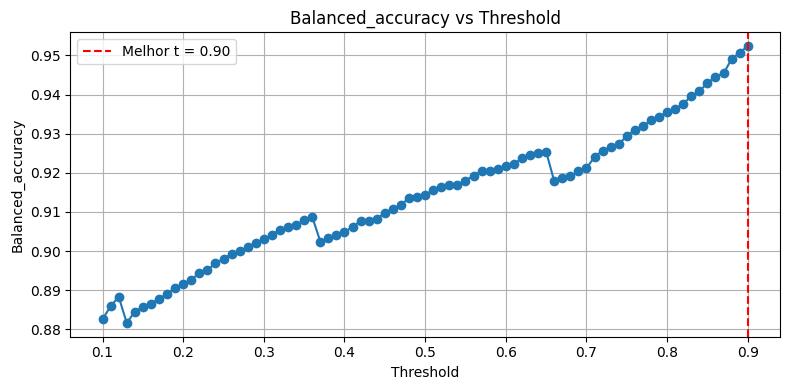

In [70]:
plt.figure(figsize=(8,4))
plt.plot(thresholds, scores, marker='o')
plt.axvline(best_threshold, linestyle='--', color='r', label=f'Melhor t = {best_threshold:.2f}')
plt.title("Balanced_accuracy vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Balanced_accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import balanced_accuracy_score

def balanced_accuracy_with_threshold(model, X_test, y_true_oh, threshold):
    """
    Calcula a balanced accuracy do modelo em X_test para um dado threshold.
    
    Args:
        model: modelo Keras treinado.
        X_test: dados de teste (input).
        y_true_oh: labels verdadeiros em one-hot encoding.
        threshold: float, limiar para decisão da classe.
        
    Returns:
        balanced_accuracy: float, acurácia balanceada no conjunto de teste.
    """
    # Predição das probabilidades
    y_pred_probs = model.predict(X_test)
    
    # Converter y_true de one-hot para labels inteiros
    y_true = np.array([
        -1 if np.all(y == 0) else np.argmax(y)
        for y in y_true_oh
    ])
    
    # Decidir classes preditas com threshold
    y_pred = []
    for p in y_pred_probs:
        if np.max(p) < threshold:
            y_pred.append(-1)
        else:
            y_pred.append(np.argmax(p))
    y_pred = np.array(y_pred)
    
    # Calcular balanced accuracy
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    
    return balanced_acc


In [72]:
balanced_acc = balanced_accuracy_with_threshold(model, X_test, y_test_aug_oh, best_threshold)
print(f"Balanced Accuracy com threshold no teste: {best_threshold:.2f}: {balanced_acc:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step
Balanced Accuracy com threshold no teste: 0.90: 0.9210


Vou aderir a métrica precision nesse problema com sigmoide, uma vez que quero otimizar meu decisor para minimizar o numero de falsos positivos (que corresponde ao número de amostras negativas que entrariam na sala sem permissão)

In [73]:
from sklearn.metrics import precision_score
def optimize_threshold_precision(y_probs, y_true, thresholds):
    best_threshold = None
    best_precision = -1
    precisions = []
    
    for t in thresholds:
        y_pred = []
        for p in y_probs:
            if np.max(p) < t:
                y_pred.append(-1)
            else:
                y_pred.append(np.argmax(p))
        y_pred = np.array(y_pred)
        
        precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        precisions.append(precision)
        
        if precision > best_precision:
            best_precision = precision
            best_threshold = t
    
    return best_threshold, best_precision, precisions

In [74]:
thresholds = np.linspace(0.1, 0.9, 81)
y_pred_probs = model.predict(X_val_aug)

# Converter y_true de one-hot para labels inteiros (mesmo jeito que você fez)
y_true = np.array([
    -1 if np.all(y == 0) else np.argmax(y)
    for y in y_val_aug_oh
])

best_threshold, best_precision, precisions = optimize_threshold_precision(y_pred_probs, y_true, thresholds)

print(f"Melhor threshold para precisão: {best_threshold:.2f} com precisão: {best_precision:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Melhor threshold para precisão: 0.90 com precisão: 0.8032


In [75]:
def precision_with_threshold(model, X_test, y_true_oh, threshold):
    """
    Calcula a precisão (precision) do modelo em X_test para um dado threshold.
    
    Args:
        model: modelo Keras treinado.
        X_test: dados de teste (input).
        y_true_oh: labels verdadeiros em one-hot encoding.
        threshold: float, limiar para decisão da classe.
        
    Returns:
        precision: float, precisão no conjunto de teste.
    """
    # Predição das probabilidades
    y_pred_probs = model.predict(X_test)
    
    # Converter y_true de one-hot para labels inteiros
    y_true = np.array([
        -1 if np.all(y == 0) else np.argmax(y)
        for y in y_true_oh
    ])
    
    # Decidir classes preditas com threshold
    y_pred = []
    for p in y_pred_probs:
        if np.max(p) < threshold:
            y_pred.append(-1)
        else:
            y_pred.append(np.argmax(p))
    y_pred = np.array(y_pred)
    
    # Calcular precisão macro (média da precisão por classe)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    
    return precision

In [76]:
precision = precision_with_threshold(model, X_test, y_test_aug_oh, best_threshold)
print(f"Precision com threshold {best_threshold:.2f}: {precision:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Precision com threshold 0.90: 0.6989


# Testando agora com melhoria de imagem antes do data augmentation

In [77]:
X_train_pp = np.array([preprocess_image_custom(img) for img in X_train])
X_val_pp = np.array([preprocess_image_custom(img) for img in X_val])
X_test_pp = np.array([preprocess_image_custom(img) for img in X_test])

Adicionar data augmentation

In [78]:
X_train_aug, y_train_aug = augment_dataset(X_train_pp, y_train, n_aug=5)
X_val_aug, y_val_aug = augment_dataset(X_val_pp, y_val, n_aug=5)

Treinando o modelo

/tmp/ipykernel_19/358042524.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_7 (Lambda)                    │ (None, 142, 142, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_7           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 2,197,446 (8.38 MB)

 Non-trainable params: 68,224 (266.50 KB)


Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 9: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.


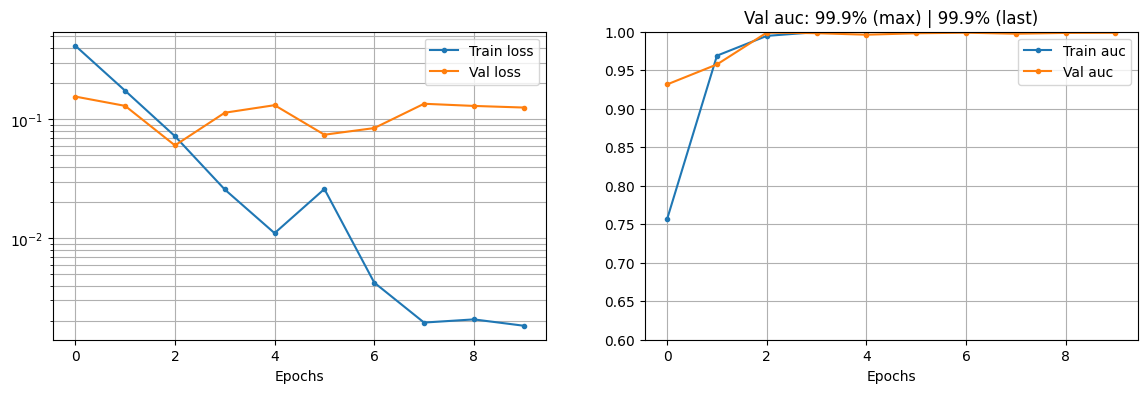

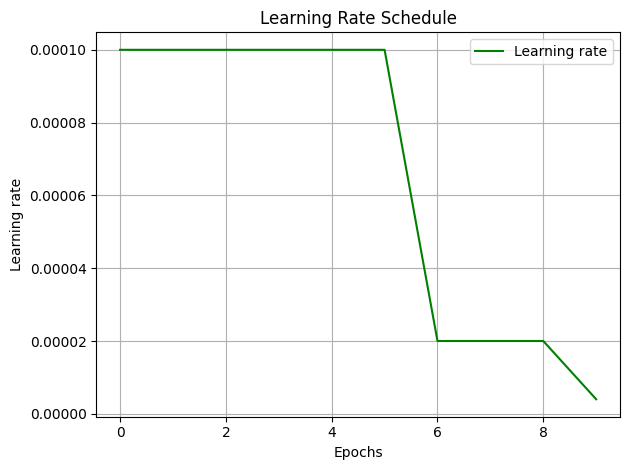

In [79]:

callbacks = [
    EarlyStopping(patience=7),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]
classes_unicas = np.unique(y)
n_classes = len(classes_unicas)
# Modelo
model = make_model_fine_tuning_sigmoid(n_classes, preprocess_input, (media, media))
model.compile(
    optimizer=Adam(learning_rate=10e-5),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
# Treinamento
history = model.fit(
    X_train_aug, y_train_aug_oh,
    validation_data=(X_val_aug, y_val_aug_oh),
    batch_size=16,
    epochs=25,
    callbacks=callbacks,
    verbose=0
)

# Plot de AUC e learning rate
plots(history, ylim=[0.6, 1])

plt.figure()
plt.plot(history.history['learning_rate'], label='Learning rate', color='green')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
y_pred_probs = model.predict(X_val_aug)
y_true = np.array([
    -1 if np.all(y == 0) else np.argmax(y)
    for y in y_val_aug_oh
])

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step


In [81]:
thresholds = np.linspace(0.1, 0.9, 81)
y_pred_probs = model.predict(X_val_aug)

# Converter y_true de one-hot para labels inteiros (mesmo jeito que você fez)
y_true = np.array([
    -1 if np.all(y == 0) else np.argmax(y)
    for y in y_val_aug_oh
])

best_threshold, best_precision, precisions = optimize_threshold_precision(y_pred_probs, y_true, thresholds)

print(f"Melhor threshold para precisão: {best_threshold:.2f} com precisão: {best_precision:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Melhor threshold para precisão: 0.90 com precisão: 0.8323


In [82]:
precision = precision_with_threshold(model, X_test_pp, y_test_aug_oh, best_threshold)
print(f"Precision com threshold {best_threshold:.2f}: {precision:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step
Precision com threshold 0.90: 0.7507


In [83]:
precision = precision_with_threshold(model, X_test, y_test_aug_oh, best_threshold)
print(f"Precision com threshold {best_threshold:.2f}: {precision:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Precision com threshold 0.90: 0.7090


Ao comparar a precision do modelo com melhoria de imagem para sem melhoria temos um aumento de 15 pontos percentuais utilizando melhoria.

### Salvando o melhor modelo com o treshold

In [84]:
# Salvar em formato HDF5 (arquivo único)
model.save('modelo_treinado.h5')

# Conclusão

Uma rede neural, ao processar as amostras pelos seus pesos e realizar o backpropagation, conseguirá identificar padrões não lineares para alcançar uma boa performance. Com esse viés, é de se esperar que utilizando imagens que tenham uma nitidez e iluminação razoável, não seja necessário uma etapa de melhoria de imagem. Porém, foi percebido que é possível sim aumentar a performance de um modelo de reconhecimento facial através dessa etapa de melhoria.